In [1]:
import numpy as np
import matplotlib.pyplot as plt
try:
     from dlroms import*
except:
     !pip install --no-deps git+https://github.com/NicolaRFranco/dlroms.git
     from dlroms import*

# **Lab 9 - Reduced order modeling**


Surrogate modeling and reduced order modeling are numerical techniques employed for approximating complex high-dimensional systems, often described in terms of partial differential equations (PDEs). The idea goes as follows.

We assume that an accurate numerical solver is available, which constitutes our ground truth reference. The latter is modeled as an input-output map of the form

$$\mathbb{R}^p\ni\boldsymbol{\mu}\mapsto \mathbf{u}_{\boldsymbol{\mu}}\in\mathbb{R}^{N_h}$$

where, given an input $\boldsymbol{\mu}\in\mathbb{R}^p$ (e.g., parameters of a PDE model) the vector $\mathbf{u}_{\boldsymbol{\mu}}$ denotes the corresponding output (e.g., solution of the PDE). Typically, $N_h$ is very large, whereas $p$ can be both large or small.

Surrogate and reduced order models (ROMs) aim at approximating this map with something else (e.g., using polynomials, neural networks, etc.). In the case of data-driven ROMs, this is achieved by fitting a suitable model over a dataset of input-output pairs, obtained from the ground truth model (often referred to as Full Order Model, FOM). Consequently, these approaches can be seen as a form of nonlinear regression in high-dimensional spaces.

Even if we were to use black-box methods, such as artificial neural networks, dealing with the high-dimensionality of the output can pose significant challenges. For this reason, it is often convenient to break the problem complexity in two parts:

1. Handling the large dimensions at output. For problems modeled in terms of PDEs, this corresponds to capturing the spatial behavior of PDE solutions;

2. Handling the parametric dependency, that is, how the input actually affects the output.

The first step is what distinguishes most of the approaches available in the literature. Here, we shall see two alternatives: a linear reduction based on Proper Orthogonal Decomposition (POD) and a nonlinear one based on autoencoders. The second step, instead, can be handled in many ways, going from neural networks to Gaussian processes.

## Methods based on **linear reduction**

The idea is fairly simple. To start, we look for a matrix $\mathbf{V}\in\mathbb{R}^{N_h\times n}$ such that

$$\mathbf{u}_{\boldsymbol{\mu}}\approx \mathbf{V}\mathbf{V}^\top \mathbf{u}_{\boldsymbol{\mu}}.$$

Why? Because that would mean that the outputs of the FOM lie (approximately) in the $n$-dimensional subspace $\mathcal{V}=\text{span}(\mathbf{V})\subset\mathbb{R}^{N_h}$, which is much smaller that the original ambient space! In fact, if we set $\mathbf{c}_{\boldsymbol{\mu}}:=\mathbf{V}^\top\mathbf{u}_{\boldsymbol{\mu}}$, we see that approximating the map $\boldsymbol{\mu}\mapsto \mathbf{u}_{\boldsymbol{\mu}}$ can now be substituted with the much simpler one of approximating $\boldsymbol{\mu}\mapsto \mathbf{c}_{\boldsymbol{\mu}}$, i.e.: given $\boldsymbol{\mu}$ we only need to predict $n$ numbers rather than $N_h$.
</br>
</br>
In what follows, we shall see how to construct $\mathbf{V}$ (POD) and how to approximate the reduced map $\boldsymbol{\mu}\mapsto \mathbf{c}_{\boldsymbol{\mu}}$ (here using neural networks).

To illustrate the idea, we directly consider a pratical problem.

We consider a parametrized nonlinear diffusion (stationary regime), describing the temperature of a mechanical component (a rod), subject to external heat sources. To account for the properties of the material, and the high temperatures, we include a nonlinear term in the conductivity as well as a radiation term (modeling heat radiated outside of the rod).

Let $\Omega\subset\mathbb{R}^{2}$ denote the rod, and let $u:\Omega\to\mathbb[0,+\infty)$ be its temperature. The equations read as follows
</br></br>
$$\begin{cases}
-\nabla\cdot(\sigma(u)\nabla u) = f-\alpha u^{4} & \text{in}\;\Omega\\\\
-\sigma(u)\nabla u \cdot \boldsymbol{n} = 0 & \text{on}\;\partial\Omega\setminus\left(\cup_{i=1}^{3}\Gamma_{i}\right)\\\\
u = T_{i} & \text{on}\;\Gamma_{i}
\end{cases}$$
</br>
where $\sigma(u):=10^3 + e^{u/8}$, whereas $\Gamma_{1},\Gamma_{2},\Gamma_{3}$ are the inner left circle, inner right circle, and the "toothed region", respectively (see the plot below).

The model parameters are
$$\boldsymbol{\mu}:=[T_1, T_2, T_3, \log_{10}f, \log_{10}\alpha].$$
</br>
Here, $T_i\in[80, 120]$, $f\in[10^{1.5}, 10^5]$ and $\alpha\in[10^{-3.5}, 10^{-1.5}].$

In [2]:
import gdown
from IPython.display import clear_output as clc
gdown.download(id = "1Yd2HE0zuepjOAj9gGF23PGSgagUHqzoS", output = "rod_mesh.xml")
mesh = fe.loadmesh("rod_mesh.xml")
Vh = fe.space(mesh, 'CG', 1)

gdown.download(id = "1hxvCJDK9BQ23I7N4NurQDCFROQssj0dJ", output = "rod_data.npz")
data = np.load("rod_data.npz")
mu, u = data['mu'], data['u']
clc()

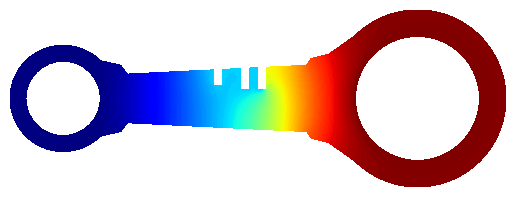

In [3]:
fe.plot(u[0], Vh)

### Principal Orthogonal Decomposition (POD)

Principal Orthogonal Decomposition is a variant of Principal Component Analysis that leverages the Singular Value Decomposition (SVD) to derive a candidate matrix $\mathbf{V}$. Specifically, given a training dataset $\{\mathbf{u}_{\boldsymbol{\mu}_i}\}_{i=1}^{N}$ and a reduced dimension $n$, the POD uses a truncated SVD to solve the following minimization problem

$$\min_{\mathbf{V}\in\mathbb{R}^{N_h\times n}}\frac{1}{N}\sum_{i=1}^{N}|\mathbf{u}_{\boldsymbol{\mu}_i}-\mathbf{V}\mathbf{V}^\top\mathbf{u}_{\boldsymbol{\mu}_i}|^2,$$

where $|\cdot|$ is the Euclidean norm. The latent dimension, $n$, can be chosen by looking at the decay on the singular values in the SVD.

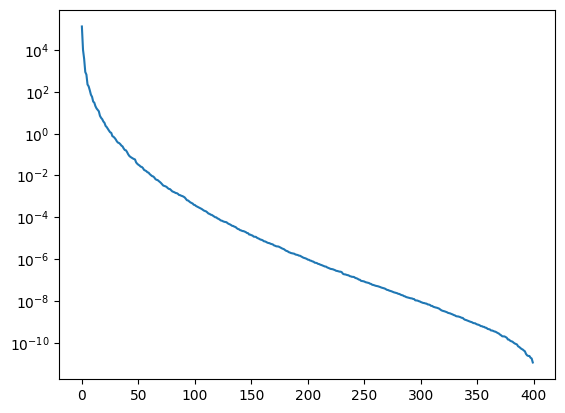

In [4]:
# Extraction of the POD basis
ntrain = 400

# Building the POD
from scipy.linalg import svd
X, s, Yt = svd(u[:ntrain].T, full_matrices=False)

n = 10
V = X[:, :n]

plt.semilogy(s)

# The first singular value essentially recovers the mean
# (we did not normalize the data)
# thus, even if we consider it, we shouldn't really plot itb

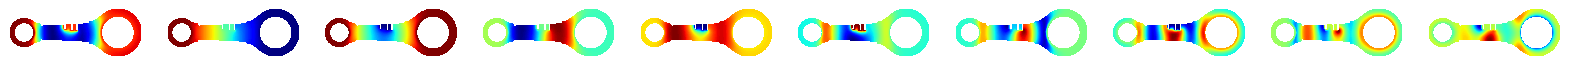

In [5]:
# Visualization
plt.figure(figsize = (20, 20))

for i in range(n):
  plt.subplot(1, n, i+1)
  fe.plot(V[:, i], Vh)

In [6]:
# Projection error assessment
# u is NdataxNh, V is NhxN, so we have to flip everythingb
uproj = u @ V @ V.T

In [7]:
# We want to use the energy norm, since the space
# is so high-dimensional and not all degrees of freedom are equally important
# so we use a l2 norm based on the grid

l2 = L2(Vh)
l2.to(dv)
clc()# TODO
# TODO
# TODO
# TODO
# TOD
# TODO

In [8]:
mu, u, uproj, V = dv.tensor(mu, u, uproj, V)
l2(u[ntrain:] - uproj[ntrain:])/l2(u[ntrain:])

tensor([0.0006, 0.0001, 0.0003, 0.0003, 0.0005, 0.0009, 0.0006, 0.0004, 0.0003,
        0.0014, 0.0002, 0.0004, 0.0027, 0.0004, 0.0013, 0.0014, 0.0001, 0.0020,
        0.0006, 0.0006, 0.0003, 0.0013, 0.0003, 0.0005, 0.0004, 0.0004, 0.0002,
        0.0006, 0.0003, 0.0002, 0.0003, 0.0003, 0.0001, 0.0002, 0.0002, 0.0006,
        0.0005, 0.0002, 0.0003, 0.0012, 0.0003, 0.0016, 0.0001, 0.0018, 0.0004,
        0.0006, 0.0002, 0.0006, 0.0003, 0.0003, 0.0002, 0.0002, 0.0003, 0.0002,
        0.0003, 0.0002, 0.0007, 0.0003, 0.0019, 0.0004, 0.0010, 0.0010, 0.0003,
        0.0011, 0.0005, 0.0002, 0.0007, 0.0011, 0.0004, 0.0010, 0.0002, 0.0001,
        0.0005, 0.0006, 0.0005, 0.0004, 0.0019, 0.0002, 0.0002, 0.0019, 0.0005,
        0.0031, 0.0002, 0.0003, 0.0003, 0.0003, 0.0018, 0.0005, 0.0002, 0.0026,
        0.0006, 0.0010, 0.0002, 0.0002, 0.0007, 0.0003, 0.0004, 0.0007, 0.0004,
        0.0004])

In [9]:
# We can do this with library utility functions
mre(l2)(u[ntrain:], uproj[ntrain:])

tensor(0.0006)

### The POD-NN approach

Once the POD matrix has been computed, we can focus on the reduced map $\boldsymbol{\mu}\mapsto\mathbf{c}_{\boldsymbol{\mu}}=\mathbf{V}^\top\mathbf{u}_{\boldsymbol{\mu}}$. In the POD-NN approach, this map is approximated using a neural network model

$$\phi:\mathbb{R}^{p}\to\mathbb{R}^{n}.$$

To this end, the same training data used for constructing the POD matrix can be used to derive a corresponding training set for $\phi$, namely $\{\boldsymbol{\mu}_i,\mathbf{c}_{\boldsymbol{\mu}_i}\}_{i=1}^{N}$ where $\mathbf{c}_{\boldsymbol{\mu}_i}=\mathbf{V}^\top\mathbf{u}_{\boldsymbol{\mu}_i}$. In this context a classical choice for the loss function is the mean squared error (MSE).

Once $\phi$ has been designed and trained, the approximation proposed by the reduced order model reads

$$\mathbf{u}_{\boldsymbol{\mu}}^{\text{POD-NN}}:=\mathbf{V}\phi(\boldsymbol{\mu})\approx \mathbf{u}_{\boldsymbol{\mu}}.$$



<mark>**Exercise 1**</mark></br>
Assemble the training data for the second phase of the POD-NN approach and train the neural network model. Then, evaluate the accuracy of the POD-NN as a whole by computing the mean relative error (MRE) in the $L^2$ norm over the test set.


How faster is the POD-NN compared to the finite element solver used to produce the training data (consider that, for the latter, it takes roughly 0.521 seconds to produce a PDE solution)? Hint: see $\textsf{perf\_counter}$ in the $\textsf{time}$ library.

In [10]:
# N_data x n
c = u @ V
c.shape

p = mu.shape[-1]
n = c.shape[-1]

architecture = Dense(p, 50, gelu) + Dense(50, 50, gelu) + Dense(50, n, None)
phi = DFNN(architecture)

phi.to(dv)
phi.He()
phi.train(mu, c, ntrain = ntrain, nvalid = 50, epochs = 50, loss = mse(euclidean))

phi.freeze()

		Train		Valid		Test
Epoch 50:	9.36e+02	1.76e+03	1.44e+03.

>> ETA: 0.16s.


Training complete. Elapsed time: 8.19 seconds.


In [14]:
# We can look at the solution to understand what this means
# Of course, we need to pass to the correct space:
# From R^n to the functional space

# Moreover, note that we here we took 500 solutions to 500
# different configurations
# Since this is fast, we can use this to simulate MC
upodnn = phi(mu) @ V.T

In [15]:
num2p(mre(l2)(u[ntrain:], upodnn[ntrain:]))

'0.72%'

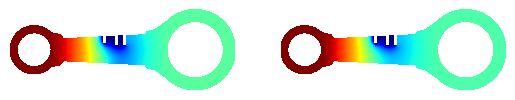

In [16]:
plt.subplot(1, 2, 1)
fe.plot(u[-1], Vh)
plt.subplot(1, 2, 2)
fe.plot(upodnn[-1], Vh)

## Methods based on **nonlinear reduction**

ROMs based on nonlinear reduction techniques are very similar in spirit, as they try to replace each FOM output $\mathbf{u}_{\boldsymbol{\mu}}\in\mathbb{R}^{N_h}$ with a corresponding reduced representation in $\mathbb{R}^{n}$ where $n\ll N_h$.

Ideally, nonlinear methods should allow one to choose smaller values of $n$ compared to linear techniques (where, in contrast, the choice of $n$ is bind to the decay of the singular values).
</br>
</br>
Mathematically speaking, this boils down to finding two nonlinear maps, an encoder $\Psi':\mathbb{R}^{N_h}\to\mathbb{R}^{n}$, and a decoder, $\Psi:\mathbb{R}^{n}\to\mathbb{R}^{N_h}$ such that

$$\mathbf{u}_{\boldsymbol{\mu}}\approx \Psi(\Psi'(\mathbf{u}_{\boldsymbol{\mu}})).$$

In particular, if we compare this idea with linear methods we see that $\Psi'$ replaces $\mathbf{V}^\top$, whereas $\Psi$ replaces $\mathbf{V}$.
</br>
</br>
When $\Psi'$ and $\Psi$ are neural network models, the composite architecture, $\Psi\circ\Psi'$ is called an **autoencoder**. As before, once the dimensionality reduction has been performed, the idea is then to focus on the reduced map $\mathbb{R}^{p}\to\mathbb{R}^{n}$, which now reads

$$\boldsymbol{\mu}\mapsto \boldsymbol{\nu}_{\boldsymbol{\mu}}:=\Psi'(\mathbf{u}_{\boldsymbol{\mu}}).$$

The variables $\boldsymbol{\nu}_{\boldsymbol{\mu}}\in\mathbb{R}^{n}$ are usually called *latent variables*. Once again, the reduced map can be approximated with several approaches, from GPs to neural networks. When neural networks are used both for the dimensionality reduction and the latent map, we call the reduced order model a "DL-ROM" (Deep Learning-based ROM).
</br>
</br>
As before, we shall directly see the idea when put into action. This time, we consider a parametrized time-dependent PDE of Navier-Stokes type. Here, the time variable is handled easily by considering $t$ as an additional parameter of the model.

We consider a very famous benchmark problem concerning a fluid flow past a cylinder. The latter is modeled using Navier-Stokes equations:

$$
\begin{cases}
\rho\left(\displaystyle \frac{\partial \boldsymbol{v}}{\partial t} + \boldsymbol{v}\cdot\nabla\boldsymbol{v}\right)-\epsilon\Delta \boldsymbol{v} + \nabla q = 0 & \text{in}\;\Omega\times(0,T],\\\\
\nabla\cdot\boldsymbol{v}= 0 & \text{in}\;\Omega\times(0, T],\\\\
\boldsymbol{v} = \boldsymbol{g} & \text{on}\;\Gamma_{\text{in}}\times(0, T]\;\cup\;\Omega\times\{0\},\\\\
\boldsymbol{v} = 0 & \text{on}\;\partial\Omega\setminus\left(\Gamma_{\text{in}}\cup\Gamma_{\text{out}}\right)\times(0, T],\\\\
q = 0 & \text{on}\;\Gamma_{\text{out}}\times(0, T]\end{cases}
$$

Here, $\epsilon>0$ is the dynamic viscosity and $\rho>0$ is the fluid density, whereas $\boldsymbol{v}:\Omega\times[0,T]\to\mathbb{R}^{2}$ is the fluid velocity field. For the sake of simplicity, we shall focus on the scalar field

$$u:=|\boldsymbol{v}|$$

describing the velocity magnitude across $\Omega$, where $|\cdot|$ is the Euclidean norm.
</br>
</br>
The solution is approximated using a P2 discretization in space. Only $N_t=141$ equispaced timesteps in $[0,T]=[0, 3.5]$ are returned. Since the FOM solver is quite expensive, a random dataset with $\log_{10}\epsilon\in[-3.5,\;-2.5]$ and $\rho\in[0.5,\;1]$ is provided.
</br>
</br>
NB: here, $\boldsymbol{\mu}:=[\log_{10}\epsilon,\rho,t]^\top$.

In [17]:
import gdown
from IPython.display import clear_output as clc
gdown.download(id = "1Sj7sMVgrOv5dM4wYbiGCyDktFpdk8VGR", output = "nstokes_data.npz")
clc()

data = np.load("nstokes_data.npz")
mu, u = data['mu'], data['u']

In [18]:
gdown.download(id = "1pkKBI4qGB2C6IGiXgAiY5CvZx0DEm88O", output = "nstokes_mesh.xml")
mesh = fe.loadmesh("nstokes_mesh.xml")
Vm = fe.space(mesh, 'CG', 2)
clc()

def visualize(umod):
    fe.animate(umod[::2], Vm, figsize = (8, 2))

In [19]:
# Notes on what the dimensions are in later cells

mu.shape, u.shape

((41, 2), (41, 141, 6477))

In [ ]:
visualize(u[0])

### Autoencoders

The idea is very simple. We just need to choose a latent dimension $n$ (how?? see the discussion during the Lab!), design two networks $\Psi':\mathbb{R}^{N_h}\to\mathbb{R}^{n}$, $\Psi:\mathbb{R}^{n}\to\mathbb{R}^{N_h}$, and train them by minimizing the reconstruction loss, i.e.

$$\text{Loss}=\frac{1}{N}\sum_{i=1}^{N}\|\mathbf{u}_{\boldsymbol{\mu}_i}-\Psi(\Psi'(\mathbf{u}_{\boldsymbol{\mu}_i}))\|^2,$$

where $\|\cdot\|$ is either the Euclidean or the $L^2$ norm. To evaluate the accuracy of the model, instead, it can be convenient distinguishing between time and PDE parameters in order to improve interpretability. Specifically, here we shall consider the following metric

$$E = \frac{1}{N_{\text{test}}}\sum_{k}\left(\frac{\int_{0}^{T}\|\mathbf{u}_{\epsilon_k,\rho_k}(t)-\tilde{\mathbf{u}}_{\epsilon_k,\rho_k}(t)\|_{L^{2}(\Omega)}dt}{\int_{0}^{T}\|\mathbf{u}_{\epsilon_k,\rho_k}(t)\|_{L^{2}(\Omega)}dt}\right).$$


In [20]:
from dlroms import*
mu, u = dv.tensor(data['mu']), dv.tensor(data['u'])

ndata, ntimes, nh = u.shape
p = mu.shape[-1]
print("Trajectories:\t%d." % ndata)
print("Timesteps:\t%d." % ntimes)
print("FOM dimension:\t%d." % nh)
print("Parameters:\t%d." % p)

mut = dv.zeros(ndata, ntimes, p+1)
times = dv.tensor(np.linspace(0, 3.5, ntimes))
for i in range(ndata):
    mut[i,:,:2] = mu[i]
    mut[i,:, 2] = times

Trajectories:	41.
Timesteps:	141.
FOM dimension:	6477.
Parameters:	2.


We can appreciate a framerate of this NS simulation.

In [22]:
mut[0, 50, :]
fe.plot(u[0, 50], Vm)

IndexError: too many indices for tensor of dimension 2

In [21]:
u = u.reshape(-1, nh)
mut = mut.reshape(-1, p+1)

<mark>**Exercise 2**</mark></br>
Design and train an autoencoder module using the data provided. Evaluate its performances using the error metric provided.

In [23]:
l2 = L2(Vm)
l2.to(dv)
clc()

ntrain = (ndata//2)*ntimes

def error(utrue, upred):
    return (l2(utrue-upred).reshape(-1, ntimes).sum(axis = -1)/l2(utrue).reshape(-1, ntimes).sum(axis = -1)).mean()

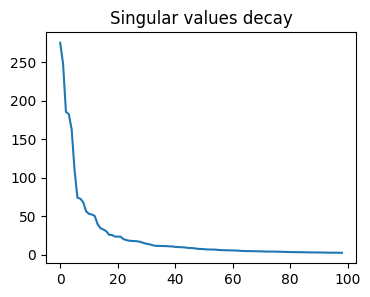

In [24]:
# Preliminary check to see if we actually need autoencoders!
from scipy.linalg import svdvals

s = svdvals(u[:ntrain].T.cpu().numpy())
plt.figure(figsize = (4, 3))
plt.plot(s[1:100])
plt.title("Singular values decay")
plt.show()

It is known that GeLU, since it is not injective, is not a good activation function for encoder.\
Instead, we will use Leaky ReLU, which is the default.

In [25]:
n = 7 # latent dimension
encoder = Dense(nh, 50) + Dense(50, n, None)
decoder = Dense(n, 50) + Dense(50, 100) + Dense(100, nh, None)
ae = DFNN(encoder + decoder)
ae.to(dv)
ae.He()

# NOTE THAT u IS BOTH THE INPUT AND THE OUTPUT!!!!
ae.train(u, u, ntrain = ntrain, epochs = 300, loss = mse(l2), error = error)
ae.freeze()

KeyboardInterrupt: 

In [ ]:
num2p(error(u[ntrain:], ae(u[ntrain:])))

'1.16%'

### The DL-ROM approach

As we mentioned, the DL-ROM approach consits in finding three neural networks</br>

$$\Psi':\mathbb{R}^{N_h}\to\mathbb{R}^{n},\quad\quad\Psi:\mathbb{R}^{n}\to\mathbb{R}^{N_{h}},$$
</br>
$$\phi:\mathbb{R}^{p}\to\mathbb{R}^{n},$$

defined such that

$$\mathbf{u}_{\boldsymbol{\mu}}\approx\Psi(\Psi'(\mathbf{u}_{\boldsymbol{\mu}}))\quad\quad\text{and}\quad\quad
\phi(\boldsymbol{\mu})\approx\Psi'(\mathbf{u}_{\boldsymbol{\mu}}).$$

In its simplest implementation, this can be achieved through two consecutive training phases: the first one, concerns training the autoencoder (as we did previously); then, the encoder and the decoder are frozen, and $\phi$ is trained.

Once the two training have been carried out, the final model reads

$$\mathbf{u}_{\boldsymbol{\mu}}\approx \Psi(\phi(\boldsymbol{\mu})).$$

<mark>**Exercise 3**</mark></br>
Leveraging the autoencoder of Ex. 2, design and train a network for the latent map. Then, evaluate the performance of the DL-ROM approach as a whole (as before, use the error metric provided). How fast is the DL-ROM when used online?

In [ ]:
from dlroms.dnns import Fourier

nu = encoder(u)

fmodes = 10
phi = DFNN(Fourier(fmodes, which = [2]) + Dense(p+1+2*fmodes, 100, gelu) + Dense(100, latent, None))

phi.He()
phi.to(dv)
#phi.train(mut, nu, ntrain = ntrain, epochs = 300, loss = mse(euclidean))
phi.download("https://drive.google.com/file/d/1-aOua52Ee3QPvF5R5bltCBf5amyv_F3d/view?usp=drive_link")
phi.freeze()

In [ ]:
dlrom = lambda mt: decoder(phi(mt))
num2p(error(u[ntrain:], dlrom(mut[ntrain:])))

'2.61%'

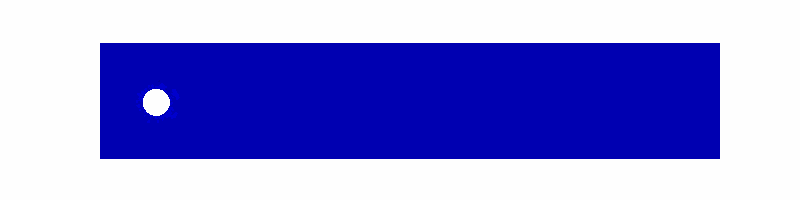

DL-ROM simulation time: 0.022s.


In [ ]:
from time import perf_counter
mu0 = dv.tensor([-3, 0.75])

mu0t = dv.zeros(ntimes, p+1)
mu0t[:, 2] = times
mu0t[:, :2] = mu0

t0 = perf_counter()
uROM = dlrom(mu0t)
t1 = perf_counter()
visualize(uROM)
print("DL-ROM simulation time: %.3fs." % (t1-t0))